In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Tridiagonal System
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]                                     # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])                            # Main diagonal
        C[i - 1] = h[i]                                       # Superdiagonal
        D[i - 1] = 6* ((y[i+1]-y[i])/h[i]-(y[i]-y[i-1])/h[i]) # Right-hand side vector
    return A, B, C, D, h

In [2]:
# Thomas Algorithm
def thomas_algorithm(a, b, c, d):
    """
        Solve the tridiagonal system using the Thomas algorithm.
        a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    
    a = a.astype(float).copy()
    b = b.astype(float).copy()
    c = c.astype(float).copy()
    d = d.astype(float).copy()

    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [3]:
def compute_second_derivatives(x, y):
    n = len(x)
    a, b, c, d, h = setup_tridiagonal_matrix(x, y)
    
    M = np.zeros(n)
    
    if n > 2:
        M_interior = thomas_algorithm(a[1:], b, c[:-1], d)
        M[1:n-1] = M_interior
    return M

In [4]:
# Evaluate the Spline
def evaluate_spline(x, y, M, x_eval):
    x_eval = np.asarray(x_eval)
    y_eval = np.zeros_like(x_eval, dtype=float)
    
    for j, xe in enumerate(x_eval):
        if xe <= x[0]:
            i = 0
        elif xe >= x[-1]:
            i = len(x) - 2
        else: i = np.searchsorted(x, xe) - 1
            
        h = x[i+1] - x[i]
        
        term1 = M[i] * (x[i + 1] - xe) ** 3 / (6 * h)
        term2 = M[i + 1] * (xe - x[i]) ** 3 / (6 * h)
        term3 = (y[i] - M[i] * h ** 2 / 6) * (x[i + 1] - xe) / h
        term4 = (y[i + 1] - M[i + 1] * h ** 2 / 6) * (xe - x[i]) / h
        
        y_eval[j] = term1 + term2 + term3 + term4
    return y_eval

# Example points
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

M = compute_second_derivatives(x, y)
print('Second derivatives M:')
print(M)

#Evaluate spline at new points
x_interpolate = np.linspace(x[0], x[-1], 300)
y_interpolate = evaluate_spline(x, y, M, x_interpolate)
# Print first 10 interpolatted points
for i in range(10):
    print(f" x = {x_interpolate[i]}, y = {y_interpolate[i]}")

Second derivatives M:
[ 0.         -4.36363636  5.45454545 -5.45454545  4.36363636  0.        ]
 x = 0.0, y = 0.0
 x = 0.016722408026755852, y = 0.028880758419821056
 x = 0.033444816053511704, y = 0.057741111444916914
 x = 0.05016722408026755, y = 0.08656065368056234
 x = 0.06688963210702341, y = 0.1153189797320322
 x = 0.08361204013377926, y = 0.14399568420460124
 x = 0.1003344481605351, y = 0.1725703617035442
 x = 0.11705685618729096, y = 0.20102260683413598
 x = 0.13377926421404682, y = 0.22933201420165136
 x = 0.15050167224080266, y = 0.25747817841136506


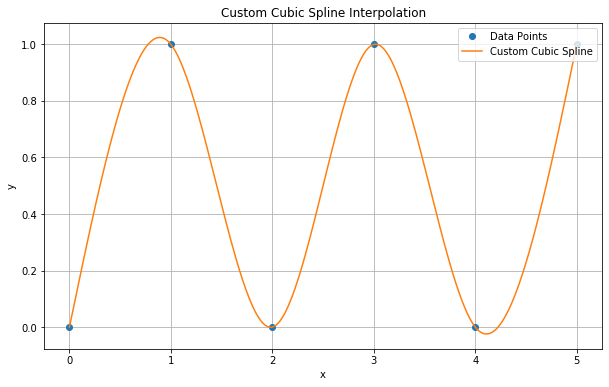

In [5]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o', label='Data Points')
plt.plot(x_interpolate, y_interpolate, label='Custom Cubic Spline')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Custom Cubic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()